In [1]:
import numpy as np

In [2]:
x = 0
th = 0.01
tau = 2
p = 0.05
pb = 0.5
t = 3000
l = 50
n_s = 100
k = 3
seed = 0

In [3]:
for ii, t in enumerate([3000, 30000]):
    for k in range(1, 11):
        for jj in range(10):
            seed = jj + (k - 1) * 10 + ii * 100
            np.random.seed(seed)
            n = n_s * k
            ret = np.zeros((t, n))
            for ki in range(k):
                xt = []
                for _ in range(t+l-1):
                    if np.random.random() < p:
                        x += 1
                    x -= x / tau
                    if x < th:
                        x = 0
                    xt.append(x)
                xt = np.array(xt)
                for i, r in enumerate(np.random.randint(l, size=n_s)):
                    ret[:, ki*n_s+i] = xt[r:r+t]
            ret *= np.random.exponential(size=(t, n))
            np.savetxt(
                "t{}/gen_n{}_k{}_l{}_t{}_seed{}.csv".format(t, str(n), str(k), str(l), str(t), str(seed)),
                ret, delimiter=","
            )

KeyboardInterrupt: 

In [3]:
t = 3000
for ii, m in enumerate([2, 0.5, 3, 1/3]):
    for k in [5]:
        for jj in range(10):
            seed = jj + (k - 1) * 10 + (ii + 1) * 1000
            np.random.seed(seed)
            n = n_s * k
            ret = np.zeros((t, n))
            for ki in range(k):
                xt = []
                for _ in range(t+l-1):
                    if np.random.random() < p:
                        x += 1
                    x -= x / tau
                    if x < th:
                        x = 0
                    xt.append(x)
                xt = np.array(xt)
                for i, r in enumerate(np.random.randint(l, size=n_s)):
                    ret[:, ki*n_s+i] = xt[r:r+t]
            ret *= np.random.gamma(shape=m, scale=1/m, size=(t, n))
            np.savetxt(
                "t{}/gen_n{}_k{}_l{}_t{}_seed{}.csv".format(t, str(n), str(k), str(l), str(t), str(seed)),
                ret, delimiter=","
            )

In [103]:
def gen_data(m, seed):
    t = 3000
    n = 500
    k = 5
    m = 0.2
    x = 0
    ret = np.zeros((t, n))
    np.random.seed(seed)
    for ki in range(k):
        xt = []
        for _ in range(t+l-1):
            if np.random.random() < p:
                x += 1
            x -= x / tau
            if x < th:
                x = 0
            xt.append(x)
        xt = np.array(xt)
        for i, r in enumerate(np.arange(100) // 2):
            ret[:, ki*n_s+i] = xt[r:r+t]
    ret *= np.random.gamma(shape=m, scale=1/m, size=ret.shape)
    ret[ret == 0] = ret[ret > 0].min()
    return ret

In [110]:
def gen_data(m, seed):
    k = 5
    x = 0
    np.random.seed(seed)
    n = n_s * k
    ret = np.zeros((t, n))
    for ki in range(k):
        xt = []
        for _ in range(t+l-1):
            if np.random.random() < p:
                x += 1
            x -= x / tau
            if x < th:
                x = 0
            xt.append(x)
        xt = np.array(xt)
        for i, r in enumerate(np.random.randint(l, size=n_s)):
            ret[:, ki*n_s+i] = xt[r:r+t]
    if noise > 0:
        ret *= np.random.gamma(shape=m, scale=1/m, size=ret.shape)
    ret[ret == 0] = ret[ret > 0].min()
    return ret

In [111]:
import cupy as cp
import igpu, pickle

In [116]:
gen_data(0.5, 0)
np.savetxt("test.csv", ret, delimiter=",")

In [118]:
for mi, m in enumerate([0.3, 0.2]):
    print(m)
    x = gen_data(m, mi)
    for i in range(10):
        model = igpu.solve(x.T, 20, 50, z_th=x.min(), random_seed=mi*10+i, corr_max=0.3, comp_rate=0.1)
        print(i, model.k, model.reconstruction_cost())

0.3
0 5 16593598.111126179
1 5 11056923.529945957
2 6 18043444.06396063
3 5 10954504.379403828
4 5 10856843.32610946
5 5 15427158.833202416
6 5 17482359.865106013
7 5 9960473.50969607
8 4 26402908.43608655
9 5 17469480.349164933
0.2
0 5 46366629.15082046
1 6 50825757.942716315
2 6 52231608.340417765
3 5 61519596.9148915
4 5 50797541.73703466


KeyboardInterrupt: 

In [98]:
model = igpu.solve(ret.T, 20, 50, z_th=ret.min(), random_seed=0, corr_max=0.3, comp_rate=0.1)

In [99]:
model.k

5

In [93]:
from matplotlib import pyplot as plt

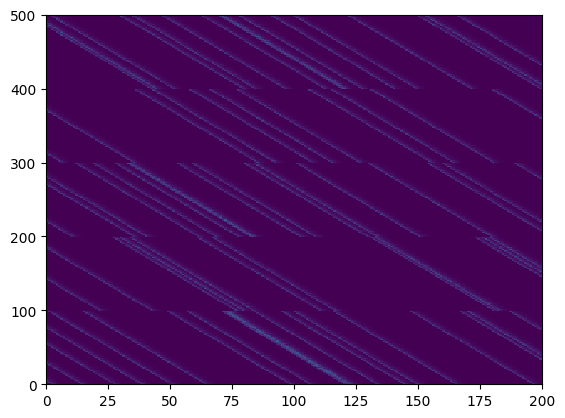

In [94]:
plt.pcolor(ret[:200].T, vmax=ret[ret > 0].mean() + 20*ret[ret > 0].std())

In [39]:
from h5py import File

In [58]:
df0 = File("save_benchmark0.mat")
df4 = File("save_benchmark4.mat")

In [87]:
tmp = np.array(df4["Diss"])
print(tmp.shape)

(50, 6, 10, 10, 3)


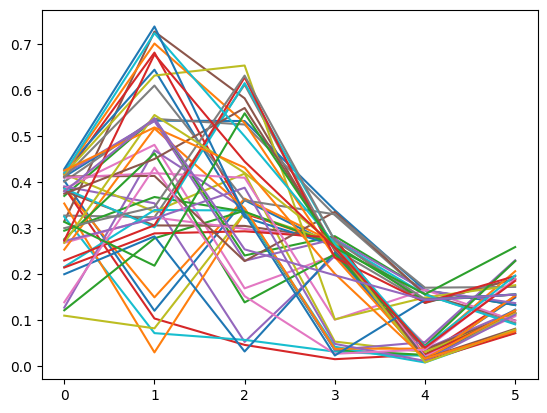

In [89]:
plt.plot(tmp[:45, 1, :6, 0, 2].T)